Importar todas las bibliotecas que se van a utilizar en este notebook.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import sklearn

Cargo los datos que voy analizar, indicando la ruta del archivo y el delimitador para separar el contenido.

Elimino las columnas que tenga valor nulo en todas las filas.

In [62]:
datos = pd.read_csv(filepath_or_buffer='./data/UF 2026.csv', delimiter=";", encoding='utf-8')
datos = datos.dropna(axis=1, how='all')
datos = datos.drop(columns='Día')
datos

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago
0,"39.731,79","39.703,50","39.796,31","39.841,72","40.133,50","40.627,62","40.823,03","40.844,79"
1,"39.735,63","39.700,94","39.801,98","39.841,72","40.146,82","40.644,55","40.825,75","40.844,79"
2,"39.739,47","39.698,37","39.807,65","39.841,72","40.160,14","40.661,48","40.828,47","40.844,79"
3,"39.743,31","39.695,81","39.813,33","39.841,72","40.173,46","40.678,43","40.831,19","40.844,79"
4,"39.747,15","39.693,25","39.819,01","39.841,72","40.186,79","40.695,38","40.833,91","40.844,79"
5,"39.751,00","39.690,68","39.824,68","39.841,72","40.200,12","40.712,34","40.836,63","40.844,79"
6,"39.754,84","39.688,12","39.830,36","39.841,72","40.213,45","40.729,31","40.839,35","40.844,79"
7,"39.758,68","39.685,56","39.836,04","39.841,72","40.226,79","40.746,28","40.842,07","40.844,79"
8,"39.762,52","39.682,99","39.841,72","39.841,72","40.240,14","40.763,26","40.844,79","40.844,79"
9,"39.759,95","39.688,65","39.841,72","39.854,94","40.256,91","40.765,97","40.844,79",NaN


Creamos una tabla para ordenar la informacion. Las columnas son:
- Mes: Numero del mes
- Dia: Numero del dia
- Fecha: El mes y dia (MM/DD)
- Valor: Valor de la UF en la fecha


Para poblar esta tabla nueva, vamor a revisar el contenido de la tabla {datos}. Para ello, vamor iterar primero por las columnas y revisamos el contenido fila por fila.

In [ ]:
columns = ['Mes', 'Dia', 'Fecha', 'Valor']

df = pd.DataFrame(columns=columns)

mes_num = {
    'Ene': 1,
    'Feb': 2,
    'Mar': 3,
    'Abr': 4,
    'May': 5,
    'Jun': 6,
    'Jul': 7,
    'Ago': 8
}

for col in datos:
    col_data = datos[col]

    num = mes_num.get(col)
    for i, value in col_data.items():

        if value == value:
            
            dia = i + 1
            fecha = datetime(year=2026, month=num, day=dia)


            info = {
                'Mes': col,
                'Dia': dia,
                'Fecha': fecha,
                'Valor': value
            }

            df.loc[len(df)] = info

df['Valor'] = (
    df['Valor']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

Generamos un grafico para comprender y visualizar la evolucion del valor de la UF durante este año.

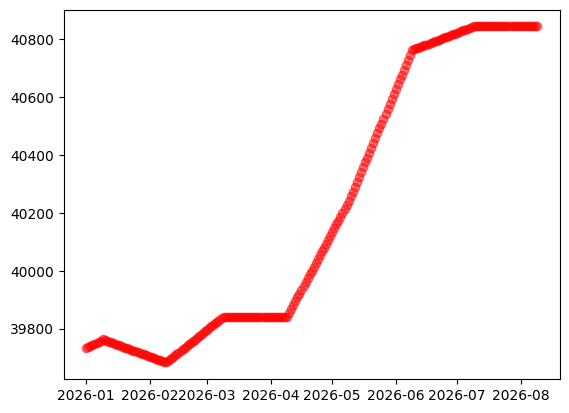

In [77]:
labelx = df['Fecha']
labely = df['Valor']

graph = plt.scatter(x=labelx, y=labely, marker='o', c='red', alpha=0.5)
graph